# Module 1 Climate Baselines and Trends
**Regions:** Cache la Poudre/Cameron Peak (CO) · Black Hills/He Sápa (SD) · Upper South Platte Front Range (CO)

Module 1 establishes the observed climate record as the baseline every later
module measures against. Nothing here is modeled or projected. It is 34 years of
gridMET.

**Three methodological commitments, made here and inherited by the rest:**

1. **Water years, not calendar years.** Calendar-year accounting splits a single
   snowpack across two buckets and manufactures variance that is an artefact of
   the calendar rather than the climate.
2. **Theil-Sen and Mann-Kendall, not OLS and Pearson.** Hydroclimate series are
   skewed, autocorrelated, and full of legitimate extremes that are not
   outliers. One anomalous year visibly tilts an OLS line through a 34-year
   record; Theil-Sen tolerates roughly 29% contamination.
3. **1991–2020 as the fixed baseline.** Thresholds computed on the full moving
   record shift as the record warms, which mechanically suppresses the trend
   being measured. This mistake always understates change.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from daear_toolkit import climate_access as ca
from daear_toolkit import climate_indicators as ci
from daear_toolkit import viz

REGIONS = [ca.POUDRE, ca.BLACK_HILLS, ca.FRONT_RANGE]
BASELINE = slice("1991", "2020")
START, END = "1991-01-01", "2024-12-31"

for r in REGIONS:
    print(f"{r.name:<45} {r.bbox}  [{r.state}]")
    print(f"  {r.notes.splitlines()[0]}\n")

Cache la Poudre/Cameron Peak                  (-106.0, 40.4, -105.0, 40.9)  [CO]
  Anchor region for the whole demo portfolio. The 2020 Cameron Peak Fire (208,913 acres, largest in Colorado history) burned the upper watershed that supplies Fort Collins and Greeley, which is why post-fire water quality here has a dollar figure attached and a motivated audience.

Black Hills (He Sapa)                         (-104.5, 43.4, -103.2, 44.7)  [SD]
  Ponderosa-dominated island range in the northern Great Plains. Included because it breaks the composite index in a useful way: lower elevation and a very different snow regime from the Colorado sites, so an index that ranks it identically to the Front Range is an index that is not actually discriminating.

Upper South Platte / Front Range foothills    (-105.7, 39.3, -105.0, 40.2)  [CO]
  Denver's municipal supply watershed, south of and adjacent to the Poudre. Adjacency is deliberate: two regions in the same physiographic setting with different fi

## Pull the observed record

gridMET: 4 km daily CONUS surface meteorology, 1979–present, served over
OPeNDAP. Four variables to start with: precipitation, max/min temperature, and
vapor pressure deficit.

VPD is the one to watch. If forced to keep a single variable for Western US
drought stress, it would be VPD: it integrates temperature and humidity into the
atmospheric demand that actually dries fuels and stresses vegetation, and it has
risen faster than precipitation has fallen.

The first read is slow as OPeNDAP is a lazy remote read and this is 34 years of
daily grids for three regions. Results are cached to `DAEAR_CACHE`, so subsequent
runs are fast. 

In [2]:
data = {}
for r in REGIONS:
    print(f"Fetching {r.name} ...", flush=True)
    data[r.key] = ca.get_gridmet(r, variables=("pr", "tmmx", "tmmn", "vpd"), start=START, end=END)
    ds = data[r.key]
    print(f"  {dict(ds.sizes)}  {ds.day.min().values.astype('datetime64[D]')} to {ds.day.max().values.astype('datetime64[D]')}")

Fetching Cache la Poudre/Cameron Peak ...
  {'day': 12419, 'lat': 12, 'lon': 24}  1991-01-01 to 2024-12-31
Fetching Black Hills (He Sapa) ...
  {'day': 12419, 'lat': 32, 'lon': 31}  1991-01-01 to 2024-12-31
Fetching Upper South Platte / Front Range foothills ...
  {'day': 12419, 'lat': 22, 'lon': 17}  1991-01-01 to 2024-12-31


## Reduce to annual series on the water year

Daily grids become regional annual series here. Two reductions at once: spatial
mean over the bbox, and temporal aggregation to the water year.

The spatial mean deserves a caveat that should travel with every number below.
These regions span 1,000+ m of elevation, and a bbox mean over that range is not
a physically meaningful location. It is an index for comparison, not a climate
for anywhere. Elevation-band stratification is the fix, and it is the obvious
extension of this module.

In [3]:
def annual_series(ds):
    """Region-mean annual series on the water year."""
    spatial = ds.mean(dim=[d for d in ds.dims if d != "day"])
    df = spatial.to_dataframe()
    df["wy"] = ci.water_year(df.index)

    out = pd.DataFrame({
        "precip_mm":  df.groupby("wy")["pr"].sum(),
        "tmax_c":     df.groupby("wy")["tmmx"].mean(),
        "tmin_c":     df.groupby("wy")["tmmn"].mean(),
        "vpd_kpa":    df.groupby("wy")["vpd"].mean(),
        # Warm-season VPD is the fire-relevant signal; the annual mean dilutes
        # it with winter months when demand is near zero regardless.
        "vpd_summer": df[df.index.month.isin([6, 7, 8])].groupby("wy")["vpd"].mean(),
        "n_days":     df.groupby("wy")["pr"].count(),
    })
    # Drop partial water years at both ends as they would otherwise appear as
    # anomalously dry years and bias the trend at the endpoints, where
    # Theil-Sen is most sensitive.
    return out[out["n_days"] > 350].drop(columns="n_days")

annual = {r.key: annual_series(data[r.key]) for r in REGIONS}
annual[ca.POUDRE.key].head()

,precip_mm,tmax_c,tmin_c,vpd_kpa,vpd_summer
wy,,,,,
1992,556.188542,12.066186,-2.335753,0.673506,1.017007
1993,588.208333,10.728127,-3.332650,0.625816,1.106916
1994,480.963889,12.218281,-2.543123,0.742424,1.376247
1995,727.536806,11.253403,-2.455144,0.623924,1.169379
1996,618.245139,11.934760,-2.478284,0.690223,1.230503


## Trends, with significance 

Theil-Sen slope for magnitude, Mann-Kendall for significance.

Autocorrelation correction is switched on. On an AR(1) series with ρ=0.7 is not
unusual for annual hydroclimate and the nominal 5% Mann-Kendall test rejects the
null about 32% of the time. The Hamed-Rao variance correction brings that to
roughly 18% without costing power. Still above nominal, so a corrected p-value
sitting just under 0.05 deserves a block bootstrap before it goes in a report;
that limitation is documented in the function rather than hidden.

In [4]:
rows = []
for r in REGIONS:
    df = annual[r.key]
    for var in ["tmax_c", "tmin_c", "precip_mm", "vpd_kpa", "vpd_summer"]:
        t = ci.theil_sen_trend(df[var].values, df.index.values, per_decade=True)
        mk = ci.mann_kendall(df[var].values, autocorr_correction=True)
        rows.append({
            "region": r.key, "variable": var,
            "trend_per_decade": round(t["slope"], 4),
            "ci_lo": round(t["lo"], 4), "ci_hi": round(t["hi"], 4),
            "p_raw": round(t["p_value"], 4),
            "p_corrected": round(mk["p_value"], 4),
            "var_inflation": round(mk["variance_inflation"], 2),
            "significant": mk["p_value"] < 0.05,
        })

trends = pd.DataFrame(rows)
trends.to_csv("../outputs/01_climate_trends.csv", index=False)
trends

,region,variable,trend_per_decade,ci_lo,ci_hi,p_raw,p_corrected,var_inflation,significant
0,poudre,tmax_c,0.2855,0.0377,0.5420,0.0289,0.0289,1.0,True
1,poudre,tmin_c,0.4057,0.1623,0.6057,0.0000,0.0000,1.0,True
2,poudre,precip_mm,-9.7245,-41.4646,23.8090,0.5253,0.5253,1.0,False
3,poudre,vpd_kpa,0.0424,0.0199,0.0608,0.0018,0.0018,1.0,True
4,poudre,vpd_summer,0.0624,0.0138,0.1270,0.0116,0.0116,1.0,True
5,black_hills,tmax_c,0.2810,-0.2129,0.6681,0.2328,0.2328,1.0,False
6,black_hills,tmin_c,0.3035,-0.0621,0.6613,0.0800,0.0800,1.0,False
7,black_hills,precip_mm,4.6703,-40.6977,41.4450,0.7685,0.7685,1.0,False
8,black_hills,vpd_kpa,0.0334,0.0004,0.0724,0.0456,0.0456,1.0,True
9,black_hills,vpd_summer,0.0811,-0.0197,0.1866,0.0800,0.0800,1.0,False


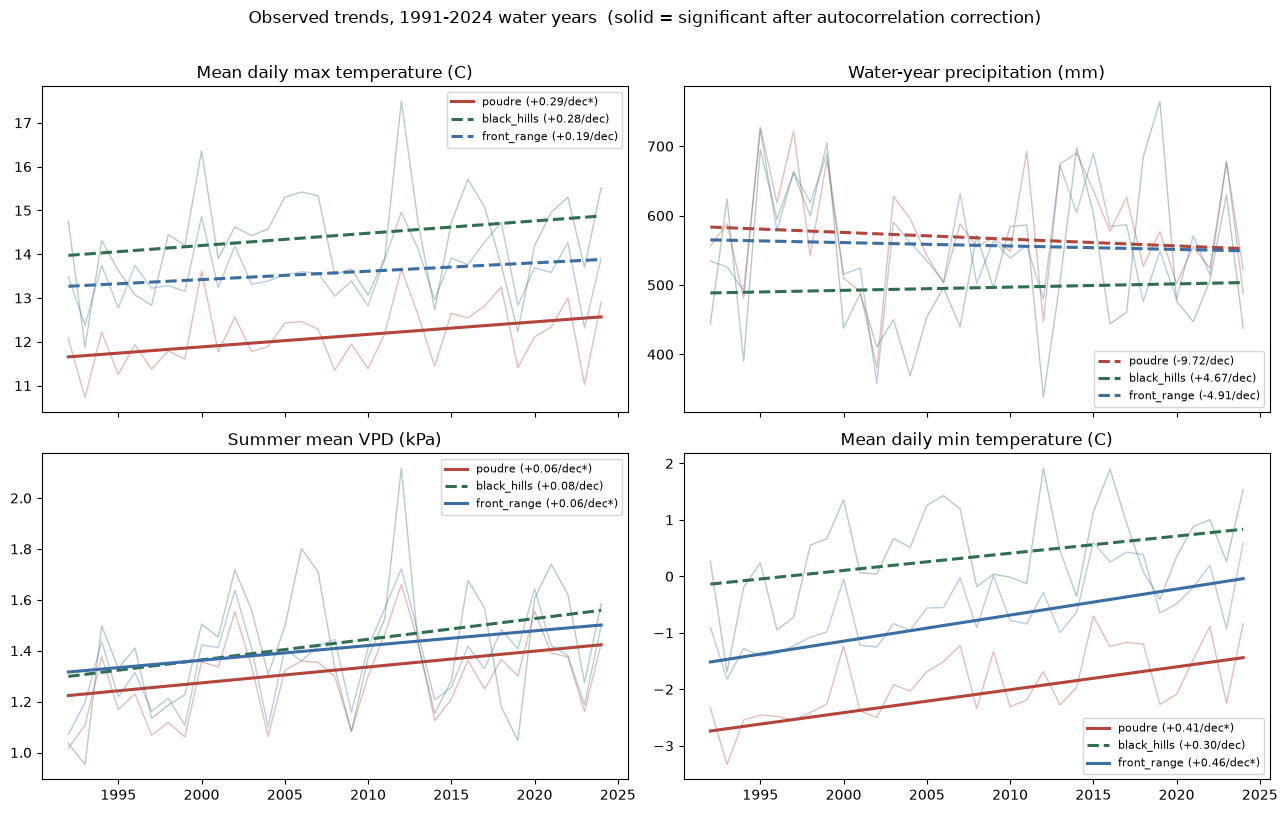

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
panels = [("tmax_c", "Mean daily max temperature (C)"), ("precip_mm", "Water-year precipitation (mm)"),
          ("vpd_summer", "Summer mean VPD (kPa)"), ("tmin_c", "Mean daily min temperature (C)")]
colors = {"poudre": "#b5443a", "black_hills": "#2f6f4e", "front_range": "#3b6ea5"}

for ax, (var, label) in zip(axes.ravel(), panels):
    for r in REGIONS:
        df = annual[r.key]
        ax.plot(df.index, df[var], color=colors[r.key], alpha=0.35, lw=1)
        t = ci.theil_sen_trend(df[var].values, df.index.values, per_decade=False)
        fit = t["intercept"] + t["slope"] * df.index.values
        sig = ci.mann_kendall(df[var].values, autocorr_correction=True)["p_value"] < 0.05
        ax.plot(df.index, fit, color=colors[r.key], lw=2.2, ls="-" if sig else "--",
                label=f"{r.key} ({t['slope']*10:+.2f}/dec{'*' if sig else ''})")
    ax.set_title(label); ax.legend(fontsize=8)

fig.suptitle("Observed trends, 1991-2024 water years  (solid = significant after autocorrelation correction)", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/01_regional_trends.png", dpi=150)
plt.show()

## Where within each region is the change concentrated?

Regional means hide the spatial structure that makes these numbers actionable.
A basin-wide warming trend of +0.3 °C/decade could be uniform, or it could be
+0.6 at the elevations that hold the snowpack and near zero elsewhere so the same
mean with entirely different water-supply consequences.

Note the multiple-comparisons problem in the p-value panel: with thousands of
pixels tested at 5%, roughly 5% will appear significant by chance. The
Benjamini-Hochberg false-discovery-rate correction below is the minimum
defensible treatment before any spatial pattern of significance gets claimed.

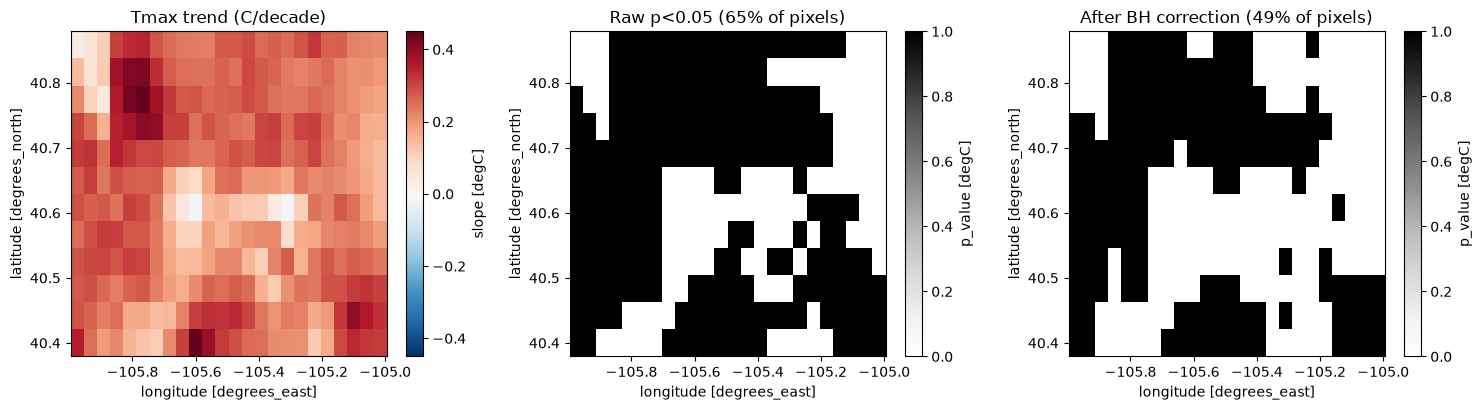

In [6]:
from scipy.stats import false_discovery_control

r = ca.POUDRE
ds = data[r.key]
annual_grid = ds["tmmx"].groupby(ds.day.dt.year).mean().rename({"year": "year"})

tm = ci.trend_map(annual_grid.chunk({"lat": 20, "lon": 20}) if hasattr(annual_grid, "chunk") else annual_grid, dim="year")

p_flat = tm["p_value"].values.ravel()
ok = np.isfinite(p_flat)
q = np.full_like(p_flat, np.nan)
q[ok] = false_discovery_control(p_flat[ok], method="bh")
q_map = tm["p_value"].copy(data=q.reshape(tm["p_value"].shape))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
tm["slope"].plot(ax=axes[0], cmap="RdBu_r", center=0)
axes[0].set_title("Tmax trend (C/decade)")
(tm["p_value"] < 0.05).plot(ax=axes[1], cmap="Greys")
axes[1].set_title(f"Raw p<0.05 ({float((tm['p_value']<0.05).mean()):.0%} of pixels)")
(q_map < 0.05).plot(ax=axes[2], cmap="Greys")
axes[2].set_title(f"After BH correction ({float((q_map<0.05).mean()):.0%} of pixels)")
plt.tight_layout()
plt.savefig("../outputs/01_poudre_trend_map.png", dpi=150)
plt.show()

## Summary

The observed baseline: 34 water years of gridMET across three regions, reduced
to Theil-Sen trends with autocorrelation-corrected significance, plus a spatial
trend map with false-discovery-rate control.

`annual` and `trends` are the inputs to Modules 2 and 3. Module 4 uses the
1991–2020 baseline computed here as the reference for projected change.

**Carry these caveats forward:**

- Regional bbox means average across 1,000+ m of elevation. They index
  comparison; they do not describe a place.
- gridMET is reanalysis-blended, not station observation. Its pre-1990 record
  is weakly constrained in mountain terrain, which is why the record starts at
  1991 here rather than 1979.
- Trends are sensitive to endpoints. 1991–2024 begins near the end of a wet
  period in Colorado, which makes drying trends look somewhat stronger than a
  1950-start would. State the window whenever a trend is quoted.